# 01 — Source: Product метрики (Firebase BigQuery)

## 0. Контекст

**Источник данных:** Firebase Public Data Program — публичный BigQuery проект `firebase-public-project.analytics_153293282`.

**Объём:**
- 5,55 млн событий за период 12.06.2018 — 30.09.2018 (111 дней)
- 14,9 тыс. уникальных пользователей
- Два приложения: `com.labpixies.flood` (Flood-It!) и `com.google.flood2` (Flood-It! 2)

**Что извлекаем — 24 product-колонки:**

| Колонка | Описание |
|---|---|
| daily_installs / daily_uninstalls / net_installs | Установки/удаления и нетто за день |
| dau / mau / wau | Daily/Monthly/Weekly Active Users |
| stickiness | DAU / MAU |
| retention_d1, retention_d7, retention_d30 | Удержание на 1/7/30 день |
| total_sessions | Число сессий за день |
| median_session_duration, avg_session_duration | Длительность сессии |
| crash_rate | Доля сессий с падением |
| onboarding_completion_rate | Доля прошедших онбординг |
| peak_hour | Час максимальной активности (0-23) |
| crash_rate_ma7, avg_session_duration_ma7 | Скользящее среднее (7 дней) |
| dau_growth_rate, dau_growth_rate_7d | Темп прироста DAU |
| install_growth_rate | Темп прироста установок |
| retention_d1_change, retention_trend | Динамика удержания |
| engagement_score | Композитная метрика вовлечённости |

**Гипотеза:** Product-метрики — основной сигнал востребованности продукта. Они уникальны на каждую пару (app_id, date) и поэтому различают наши два приложения. Здесь мы анализируем их распределение, динамику и взаимосвязи.


In [1]:
import sys
from pathlib import Path

_HERE = Path.cwd()
_ROOT = _HERE.parent if _HERE.name == "notebooks" else _HERE
sys.path.insert(0, str(_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from src.feature_engineering import load_dataset
from notebooks._common import (
    APP_PALETTE, FIGSIZE_DEFAULT, FIGSIZE_WIDE,
    save_figure, theme_setup, app_label,
)

theme_setup()
np.random.seed(42)

NOTEBOOK_SLUG = "01_source_product"
df = load_dataset()
print(f"Dataset: {df.shape}")


Dataset: (222, 60)


In [2]:
PRODUCT_COLS = [
    "daily_installs", "daily_uninstalls", "net_installs",
    "dau", "mau", "wau", "stickiness",
    "retention_d1", "retention_d7", "retention_d30",
    "total_sessions", "median_session_duration", "avg_session_duration",
    "crash_rate", "onboarding_completion_rate", "peak_hour",
    "crash_rate_ma7", "avg_session_duration_ma7",
    "dau_growth_rate", "dau_growth_rate_7d", "install_growth_rate",
    "retention_d1_change", "retention_trend",
    "engagement_score",
]
assert len(PRODUCT_COLS) == 24
print(f"PRODUCT_COLS: {len(PRODUCT_COLS)} колонок")


PRODUCT_COLS: 24 колонок


## 1. Загрузка и общая структура

In [3]:
from notebooks._common import split_by_app
df_f1, df_f2 = split_by_app(df)
print(f"Flood-It!  shape: {df_f1[PRODUCT_COLS].shape}")
print(f"Flood-It! 2 shape: {df_f2[PRODUCT_COLS].shape}")
print()
print("dtypes Product-колонок:")
print(df[PRODUCT_COLS].dtypes.value_counts())


Flood-It!  shape: (111, 24)
Flood-It! 2 shape: (111, 24)

dtypes Product-колонок:
float64    20
int64       4
Name: count, dtype: int64


In [4]:
# Просмотр первых строк f1 и f2
display(df_f1[["date"] + PRODUCT_COLS[:6]].head())
display(df_f2[["date"] + PRODUCT_COLS[:6]].head())


,date,daily_installs,daily_uninstalls,net_installs,dau,mau,wau
0,2018-06-12,13.0,13.0,0.0,134,134,134
1,2018-06-13,10.0,13.0,-3.0,144,227,227
2,2018-06-14,20.0,22.0,-2.0,142,301,301
3,2018-06-15,12.0,18.0,-6.0,145,375,375
4,2018-06-16,9.0,7.0,2.0,112,417,417


,date,daily_installs,daily_uninstalls,net_installs,dau,mau,wau
0,2018-06-12,12.0,0.0,12.0,315,315,315
1,2018-06-13,15.0,0.0,15.0,371,542,542
2,2018-06-14,20.0,0.0,20.0,361,693,693
3,2018-06-15,21.0,0.0,21.0,343,816,816
4,2018-06-16,16.0,0.0,16.0,309,924,924


## 2. Качество данных

In [5]:
# NaN counts по 24 колонкам
nan_summary = pd.DataFrame({
    "Flood-It!":   df_f1[PRODUCT_COLS].isna().sum(),
    "Flood-It! 2": df_f2[PRODUCT_COLS].isna().sum(),
})
nan_summary["sum"] = nan_summary.sum(axis=1)
display(nan_summary.sort_values("sum", ascending=False).drop("sum", axis=1))


,Flood-It!,Flood-It! 2
retention_d30,79,98
retention_d7,36,67
retention_d1_change,16,35
retention_trend,8,31
onboarding_completion_rate,4,29
retention_d1,9,20
dau_growth_rate_7d,7,7
install_growth_rate,1,2
dau_growth_rate,1,1
stickiness,0,0


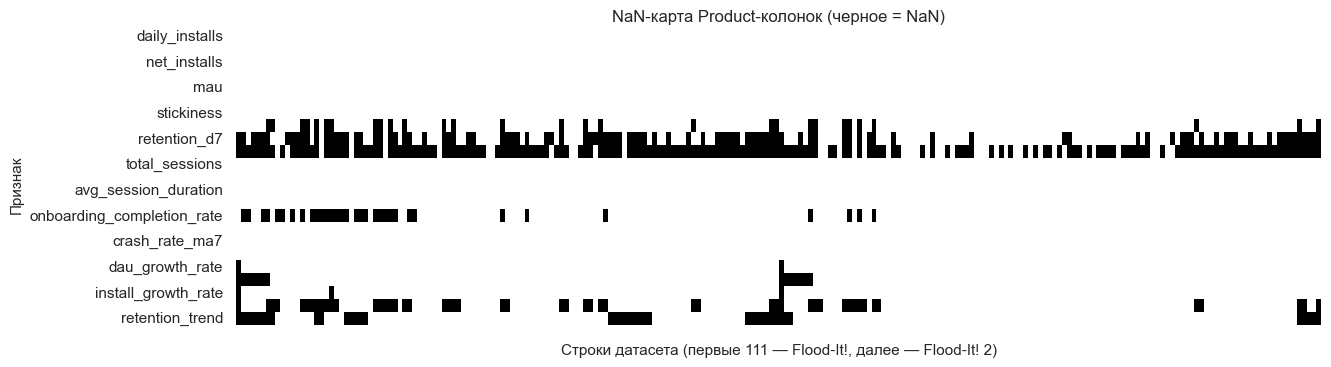

In [6]:
# NaN heatmap для всего датасета по PRODUCT_COLS
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    df[PRODUCT_COLS].isna().T.astype(int),
    cmap="binary", cbar=False, xticklabels=False, ax=ax,
)
ax.set_title("NaN-карта Product-колонок (черное = NaN)")
ax.set_ylabel("Признак")
ax.set_xlabel("Строки датасета (первые 111 — Flood-It!, далее — Flood-It! 2)")
save_figure("nan_heatmap", NOTEBOOK_SLUG)
plt.show()


In [7]:
# Дубликаты по (app_id, date)
dup_check = df.groupby(["app_id", "date"]).size()
assert (dup_check == 1).all(), f"Найдены дубликаты: {dup_check[dup_check > 1]}"
print(f"Дубликаты по (app_id, date): нет (все группы по 1 строке)")
print(f"Всего уникальных пар: {len(dup_check)}")


Дубликаты по (app_id, date): нет (все группы по 1 строке)
Всего уникальных пар: 222


In [8]:
# Sanity: процентные колонки в [0,1]
PCT_COLS = ["stickiness", "retention_d1", "retention_d7", "retention_d30",
            "crash_rate", "onboarding_completion_rate"]
for col in PCT_COLS:
    s = df[col].dropna()
    assert (s >= 0).all() and (s <= 1).all(), f"{col} имеет значения вне [0,1]: min={s.min()}, max={s.max()}"
    print(f"{col}: [{s.min():.4f}, {s.max():.4f}] — OK")


stickiness: [0.0262, 1.0000] — OK
retention_d1: [0.0286, 1.0000] — OK
retention_d7: [0.0182, 0.2500] — OK
retention_d30: [0.0189, 0.2500] — OK
crash_rate: [0.0013, 0.6687] — OK
onboarding_completion_rate: [0.0435, 1.0000] — OK


In [9]:
from notebooks._common import check_inf_columns
inf_cols_product = check_inf_columns(df, PRODUCT_COLS)
if inf_cols_product:
    # Покажем сколько inf на колонку
    for c in inf_cols_product:
        n_inf = np.isinf(df[c].dropna()).sum()
        print(f"  {c}: {n_inf} inf-значений")


⚠ inf-значения найдены в: ['install_growth_rate']
  → будут трактоваться как NaN при описательной статистике и моделировании.
  install_growth_rate: 8 inf-значений


**NaN-стратегия в этом ноутбуке:**

Только описательная статистика и визуализация — пропуски *не* импьютируются, описываются.
Импутация и фильтрация выполняются в `src/feature_engineering.py` (VIF + permutation importance)
перед обучением моделей.

Для метрик с заметным числом пропусков (например, `retention_d7` у Flood-It! 2 — 44/111 валидных)
сравнение распределений ограниченно. Это отражено в подписях фигур через `(n₁, n₂)`-аннотацию.


## 3. Описательная статистика

In [10]:
print("=== Flood-It! describe ===")
display(df_f1[PRODUCT_COLS].describe().T.round(3))


=== Flood-It! describe ===


C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
daily_installs,111.0,24.928,11.948,0.000,18.000,26.000,31.000,55.000
daily_uninstalls,111.0,23.045,8.414,5.000,18.000,22.000,27.500,52.000
net_installs,111.0,1.883,11.267,-50.000,-1.000,3.000,8.000,23.000
dau,111.0,246.198,78.651,64.000,200.500,275.000,292.000,395.000
mau,111.0,2536.901,719.735,134.000,2433.000,2841.000,2956.500,3122.000
wau,111.0,964.450,235.456,134.000,897.500,1030.000,1094.000,1285.000
stickiness,111.0,0.126,0.126,0.026,0.082,0.097,0.112,1.000
retention_d1,102.0,0.246,0.132,0.038,0.167,0.226,0.313,1.000
retention_d7,75.0,0.081,0.045,0.018,0.047,0.069,0.109,0.222
retention_d30,32.0,0.047,0.024,0.019,0.032,0.040,0.054,0.118


In [11]:
print("=== Flood-It! 2 describe ===")
display(df_f2[PRODUCT_COLS].describe().T.round(3))


=== Flood-It! 2 describe ===


C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
daily_installs,111.0,12.505,7.861,0.000,8.000,11.000,16.000,44.000
daily_uninstalls,111.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
net_installs,111.0,12.505,7.861,0.000,8.000,11.000,16.000,44.000
dau,111.0,272.495,181.675,125.000,161.000,203.000,325.000,888.000
mau,111.0,2519.108,977.585,315.000,1629.000,2516.000,3376.500,4067.000
wau,111.0,1050.054,520.953,315.000,604.500,721.000,1480.000,2545.000
stickiness,111.0,0.136,0.136,0.033,0.062,0.107,0.139,1.000
retention_d1,91.0,0.231,0.124,0.029,0.125,0.222,0.326,0.625
retention_d7,44.0,0.119,0.060,0.023,0.077,0.106,0.147,0.250
retention_d30,13.0,0.123,0.053,0.077,0.083,0.100,0.143,0.250


In [12]:
from notebooks._common import comparison_table
KEY_PRODUCT = ["dau", "stickiness", "retention_d7", "crash_rate",
               "onboarding_completion_rate", "engagement_score", "total_sessions"]
display(comparison_table(df_f1, df_f2, KEY_PRODUCT))


,metric,f1_median,f2_median,f1_std,f2_std,delta_pct
0,dau,275.0000,203.0000,78.6511,181.6751,-26.2
1,stickiness,0.0970,0.1074,0.1257,0.1359,10.7
2,retention_d7,0.0690,0.1056,0.0449,0.0602,53.1
3,crash_rate,0.0983,0.0663,0.1125,0.0322,-32.5
4,onboarding_completion_rate,0.4615,0.2546,0.2080,0.1957,-44.8
5,engagement_score,0.2402,0.2558,0.0936,0.0884,6.5
6,total_sessions,350.0000,277.0000,104.4873,158.7481,-20.9


## 4. Распределения

C:\Users\Анастасия\AppData\Local\Temp\ipykernel_14624\4217744878.py:15: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout(rect=(0, 0, 1, 0.97))
C:\Users\Анастасия\AppData\Local\Temp\ipykernel_14624\4217744878.py:15: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout(rect=(0, 0, 1, 0.97))


C:\7 семестр\пиздец\notebooks\_common.py:74: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.savefig(out_path, dpi=200, bbox_inches="tight")
C:\7 семестр\пиздец\notebooks\_common.py:74: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(out_path, dpi=200, bbox_inches="tight")


C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


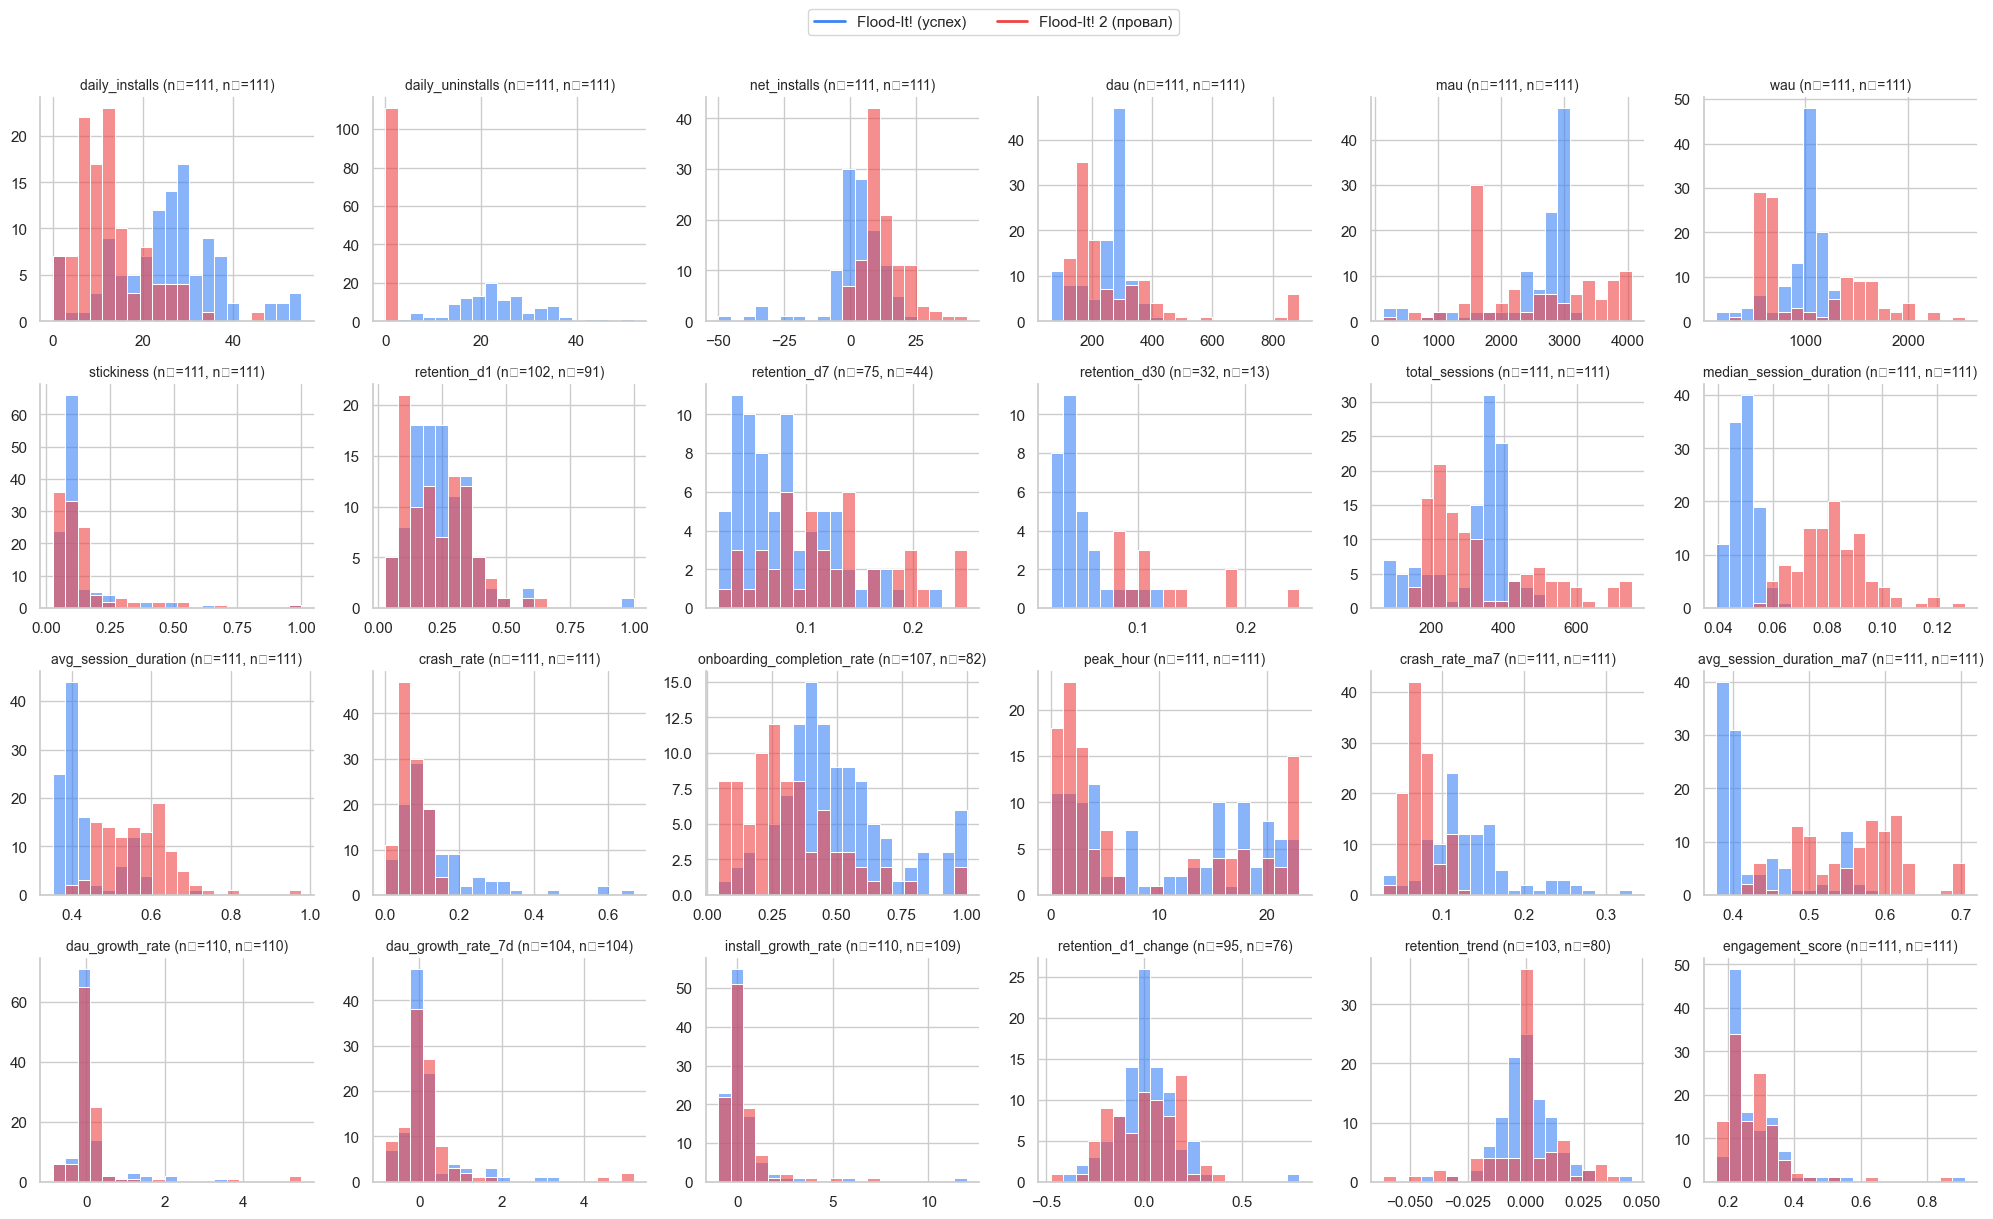

In [13]:
from notebooks._common import annotate_sample_size, add_app_legend

fig, axes = plt.subplots(4, 6, figsize=(20, 12))
for i, col in enumerate(PRODUCT_COLS):
    ax = axes.flat[i]
    sns.histplot(
        data=df, x=col, hue="app_id",
        palette=APP_PALETTE, kde=False, ax=ax,
        bins=20, alpha=0.6, legend=False,
    )
    annotate_sample_size(ax, df_f1, df_f2, col)
    ax.set_xlabel("")
    ax.set_ylabel("")
add_app_legend(fig)
plt.tight_layout(rect=(0, 0, 1, 0.97))
save_figure("histograms_product", NOTEBOOK_SLUG)
plt.show()


C:\Users\Анастасия\AppData\Local\Temp\ipykernel_14624\1385869302.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([app_label(t.get_text()) for t in ax.get_xticklabels()], rotation=15)
C:\Users\Анастасия\AppData\Local\Temp\ipykernel_14624\1385869302.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([app_label(t.get_text()) for t in ax.get_xticklabels()], rotation=15)
C:\Users\Анастасия\AppData\Local\Temp\ipykernel_14624\1385869302.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([app_label(t.get_text()) for t in ax.get_xticklabels()], rotation=15)
C:\Users\Анастасия\AppData\Local\Temp\ipykernel_14624\1385869302.py:10: UserWarning: set_ticklabels() should only be used with 

C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


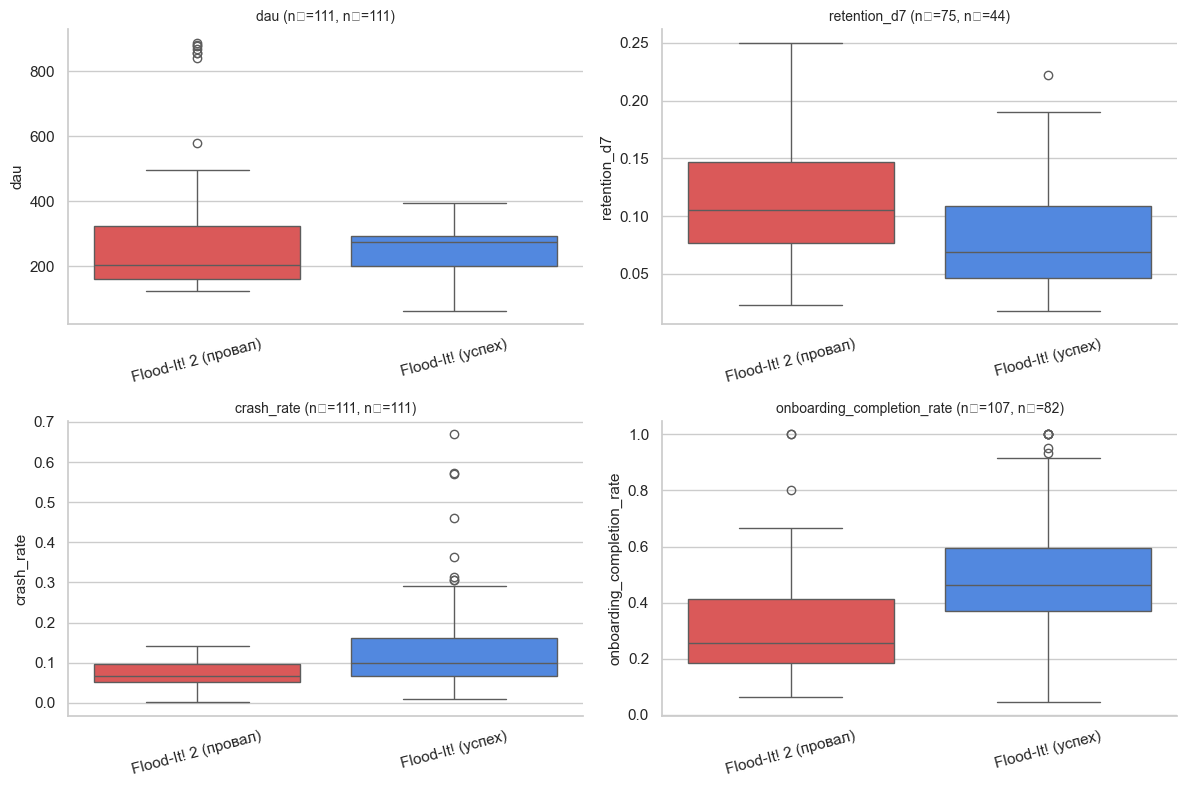

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(["dau", "retention_d7", "crash_rate", "onboarding_completion_rate"]):
    ax = axes.flat[i]
    sns.boxplot(
        data=df, x="app_id", y=col,
        hue="app_id", palette=APP_PALETTE, legend=False, ax=ax,
    )
    annotate_sample_size(ax, df_f1, df_f2, col, base_title=col)
    ax.set_xlabel("")
    ax.set_xticklabels([app_label(t.get_text()) for t in ax.get_xticklabels()], rotation=15)
plt.tight_layout()
save_figure("boxplots_product", NOTEBOOK_SLUG)
plt.show()


## 5. Динамика во времени

C:\Users\Анастасия\AppData\Local\Temp\ipykernel_14624\1034780073.py:15: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout(rect=(0, 0, 1, 0.96))
C:\Users\Анастасия\AppData\Local\Temp\ipykernel_14624\1034780073.py:15: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout(rect=(0, 0, 1, 0.96))


C:\7 семестр\пиздец\notebooks\_common.py:74: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.savefig(out_path, dpi=200, bbox_inches="tight")
C:\7 семестр\пиздец\notebooks\_common.py:74: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(out_path, dpi=200, bbox_inches="tight")


C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


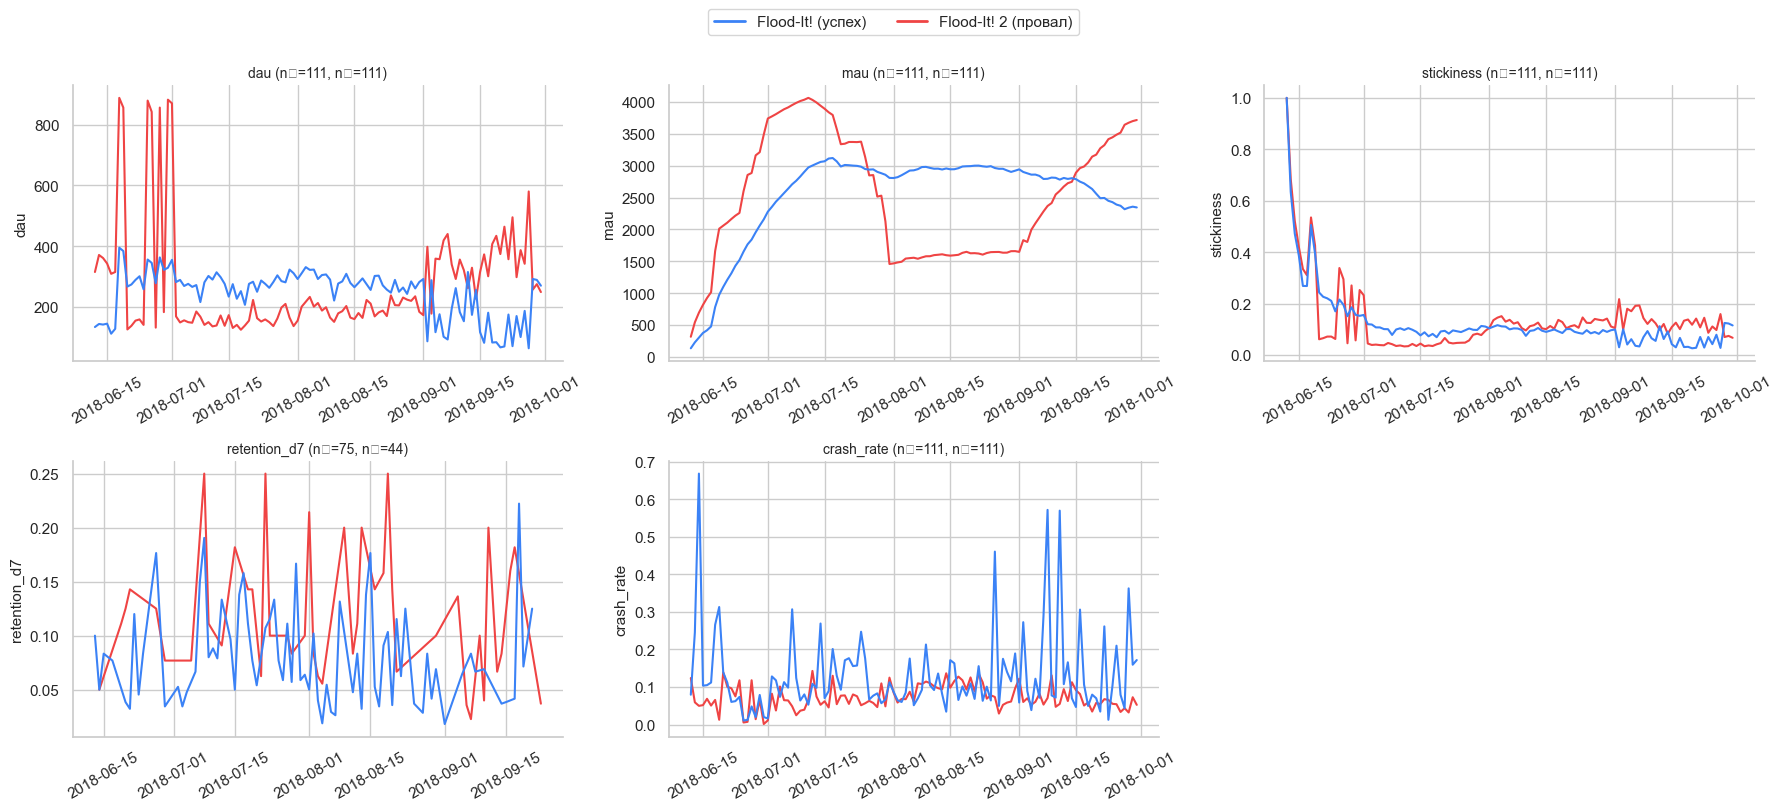

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for i, col in enumerate(["dau", "mau", "stickiness", "retention_d7", "crash_rate"]):
    ax = axes.flat[i]
    sns.lineplot(
        data=df, x="date", y=col,
        hue="app_id", palette=APP_PALETTE,
        legend=False, ax=ax,
    )
    annotate_sample_size(ax, df_f1, df_f2, col)
    ax.set_xlabel("")
    for label in ax.get_xticklabels():
        label.set_rotation(30)
axes.flat[5].set_visible(False)
add_app_legend(fig)
plt.tight_layout(rect=(0, 0, 1, 0.96))
save_figure("timeseries_product", NOTEBOOK_SLUG)
plt.show()


## 6. Корреляции внутри группы

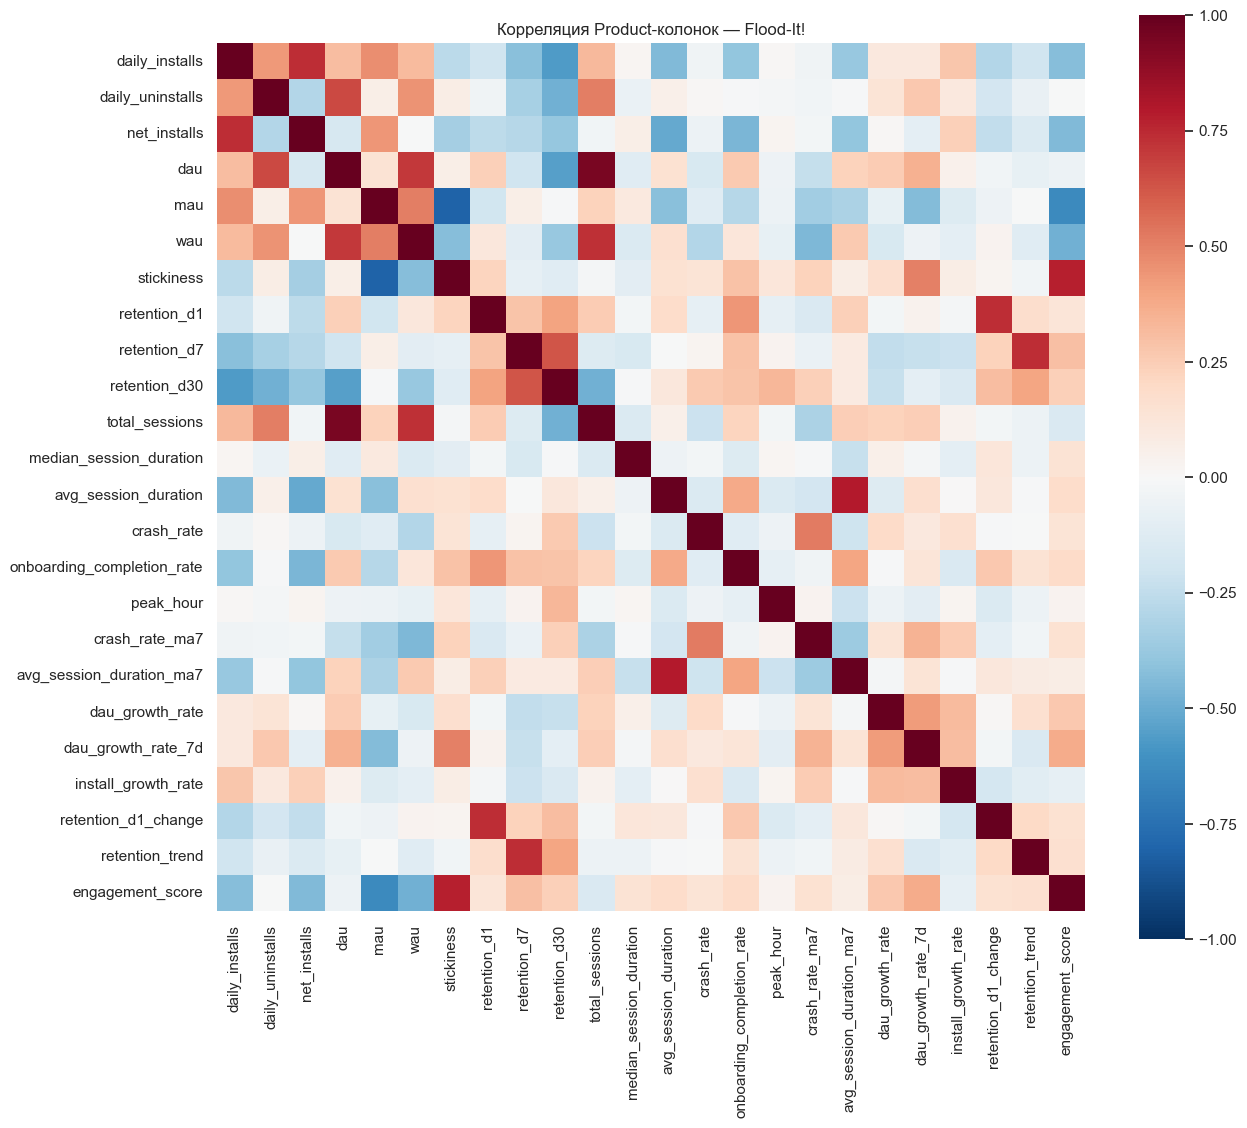

In [16]:
fig, ax = plt.subplots(figsize=(14, 12))
corr_f1 = df_f1[PRODUCT_COLS].corr()
sns.heatmap(corr_f1, cmap="RdBu_r", center=0, vmin=-1, vmax=1, annot=False, square=True, ax=ax)
ax.set_title("Корреляция Product-колонок — Flood-It!")
save_figure("corr_product_f1", NOTEBOOK_SLUG)
plt.show()


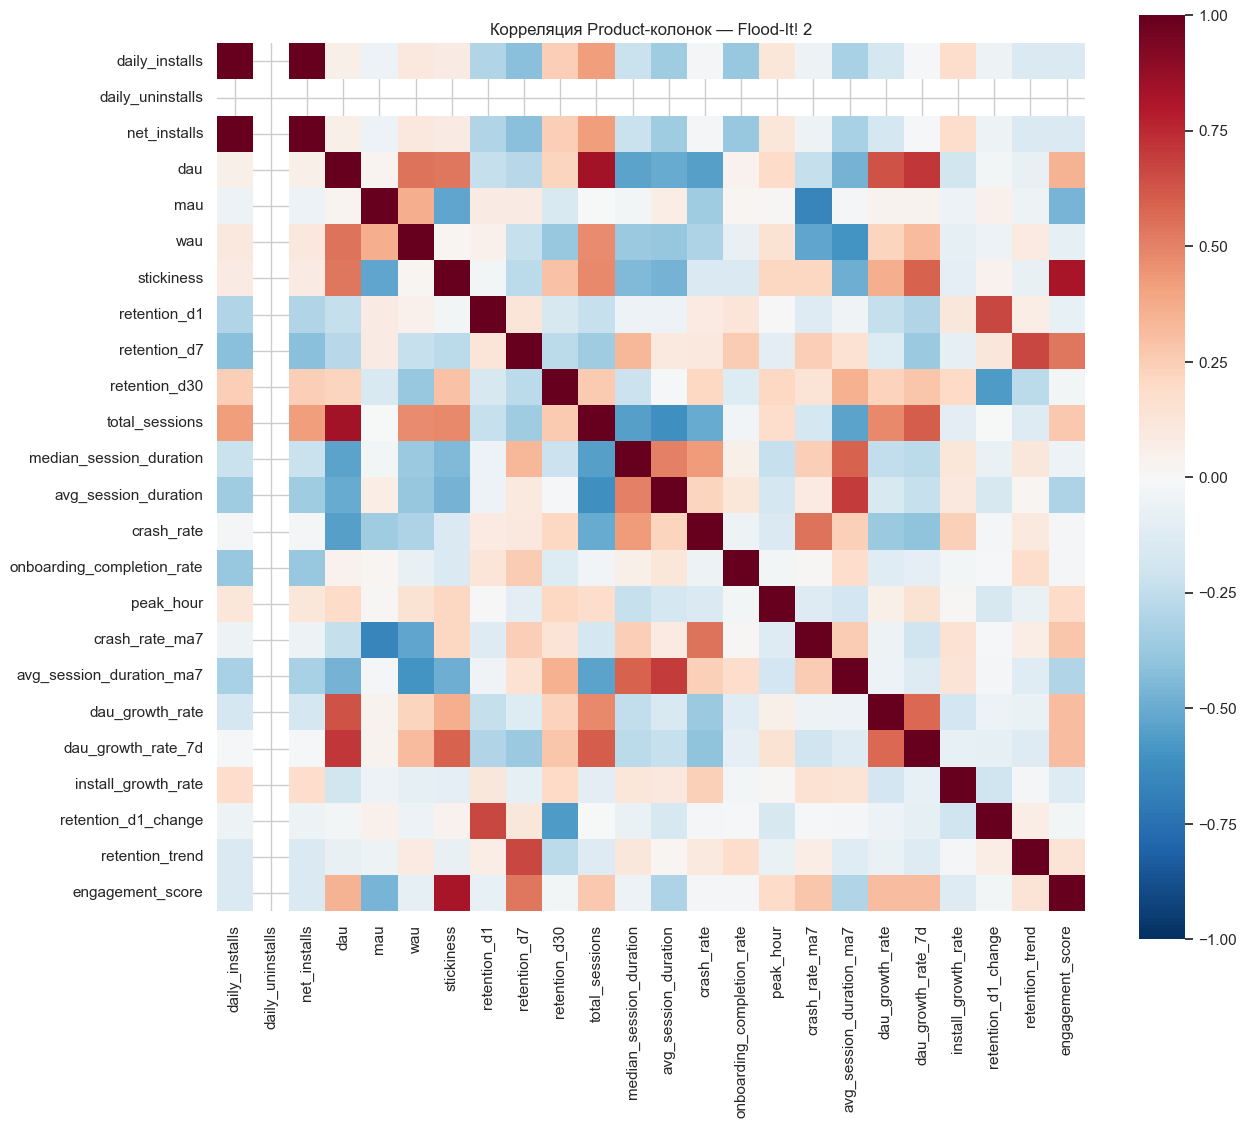

In [17]:
fig, ax = plt.subplots(figsize=(14, 12))
corr_f2 = df_f2[PRODUCT_COLS].corr()
sns.heatmap(corr_f2, cmap="RdBu_r", center=0, vmin=-1, vmax=1, annot=False, square=True, ax=ax)
ax.set_title("Корреляция Product-колонок — Flood-It! 2")
save_figure("corr_product_f2", NOTEBOOK_SLUG)
plt.show()


In [18]:
from notebooks._common import top_correlated_pairs
print("Flood-It! — топ-5 |corr|>0.7:")
print(top_correlated_pairs(corr_f1, threshold=0.7, n=5))
print()
print("Flood-It! 2 — топ-5 |corr|>0.7:")
print(top_correlated_pairs(corr_f2, threshold=0.7, n=5))


Flood-It! — топ-5 |corr|>0.7:
dau                   total_sessions              0.949655
mau                   stickiness                 -0.810528
avg_session_duration  avg_session_duration_ma7    0.794280
stickiness            engagement_score            0.776692
retention_d7          retention_trend             0.739837
dtype: float64

Flood-It! 2 — топ-5 |corr|>0.7:
daily_installs  net_installs          1.000000
dau             total_sessions        0.836445
stickiness      engagement_score      0.827206
dau             dau_growth_rate_7d    0.713471
dtype: float64


## 7. Особенности по продукту

### Выводы по Product-метрикам

**Характер Flood-It! (com.labpixies.flood) — успешный продукт:**
- DAU медиана = **275**, диапазон 64–395 — стабильная аудитория на протяжении всех 111 дней наблюдений.
- Stickiness медиана = **0.097** (DAU/MAU ≈ 10%), стд. = 0.126; периодически достигает 1.0, что указывает на дни с очень высокой активностью.
- Retention_d7 медиана = **0.069** (6.9%), диапазон 1.8–22.2% — реальный возврат пользователей фиксируется.
- Crash_rate медиана = **0.098** (~10%), стд. = 0.113 — выше порога Google Play в 2%; требует внимания в feature engineering.
- Onboarding_completion_rate медиана = **0.462** — почти половина пользователей проходит онбординг.
- Engagement_score медиана = **0.240**, стабильный (стд. = 0.094).

**Характер Flood-It! 2 (com.google.flood2) — провальный продукт:**
- DAU медиана = **203** (−26% к Flood-It!), но стд. = 181.7 — высокая волатильность, аудитория нестабильна.
- Daily_uninstalls = **0 для всех дней** — продукт не был в магазине с доступными удалениями; это артефакт снятия с публикации.
- Retention_d7 медиана = **0.106** (формально выше Flood-It!), но доступно лишь 44/111 значений — за пределами активного периода данных нет.
- Crash_rate медиана = **0.066** — ниже, чем у Flood-It!, что неожиданно; возможно, аварии в снятом продукте не логировались.
- Onboarding_completion_rate медиана = **0.255** (−44.8% к Flood-It!) — ключевое отличие в удержании на начальном этапе.
- Пропуски: retention_d30 имеет 98 NaN из 111 (88%), retention_d7 — 67 NaN (60%); данных о долгосрочном удержании почти нет.

**Ключевые сигналы для предсказания востребованности:**
- `dau` и `total_sessions` (corr = 0.949 для Flood-It!) — сильнейший парный сигнал, но коллинеарны.
- `retention_d7` — ключевой индикатор; несмотря на 42% NaN, именно он определяет долгосрочную востребованность.
- `stickiness` — высокая корреляция с `mau` (−0.811) и `engagement_score` (0.777); после VIF нужно оставить только один.
- `onboarding_completion_rate` — сильно разделяет f1 и f2 (delta = −44.8%), полезен как предиктор.

**Мультиколлинеарность — топ-5 пар (Flood-It!):**
- `dau` / `total_sessions`: corr = **0.950** — почти идеальная линейная зависимость.
- `mau` / `stickiness`: corr = **−0.811** — MAU и stickiness обратно связаны (при росте знаменателя stickiness падает).
- `avg_session_duration` / `avg_session_duration_ma7`: corr = **0.794** — скользящее среднее почти дублирует переменную.
- `stickiness` / `engagement_score`: corr = **0.777** — engagement_score агрегирует stickiness.
- `retention_d7` / `retention_trend`: corr = **0.740** — тренд коллинеарен уровню.

Все пары с |corr| > 0.7 подлежат VIF-анализу (порог 10.0) перед подачей в ядерную регрессию.


## 8. Сохранение фигур

In [19]:
from notebooks._common import _PROJECT_ROOT
fig_dir = _PROJECT_ROOT / "figures" / NOTEBOOK_SLUG
print("Сохранённые фигуры:")
for p in sorted(fig_dir.glob("*.pdf")):
    print(f"  - {p.name}")


Сохранённые фигуры:
  - boxplots_product.pdf
  - corr_product_f1.pdf
  - corr_product_f2.pdf
  - histograms_product.pdf
  - nan_heatmap.pdf
  - timeseries_product.pdf
